### Oppgave 1.1
Plot av det loagitmiske potensialet F(u) for $u \in [-1,1]$ for $\theta = [0.7,1.6]$ med $ \theta < \theta_c$, $ \theta = \theta_c$ og $ \theta > \theta_c$ for en kritisk temperatur $\theta_c = 1.5$

In [475]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fft, fftfreq, fftshift, ifft, ifftshift
import sympy as sy
from sympy import sin, cos, exp
import pandas as pd

plt.rcParams.update({
     "font.family": "serif",             
    "mathtext.fontset": "cm",
    "font.size": 12,                
    "axes.titlesize": 16,           
    "axes.labelsize": 16,           
    "xtick.labelsize": 10,          
    "ytick.labelsize": 10,          
    "legend.fontsize": 10,          
    "lines.linewidth": 2,           
    "axes.grid": True,              
    "grid.linestyle": "--",         
    "grid.alpha": 0.6, 
})

In [476]:
theta_vals = np.linspace(0.7,1.6,10)
theta_c = 1.5
u_start = -1
u_stop = 1
def plot_logF(u_start,u_stop,theta_vals, theta_c):
    for j in range(len(theta_vals)):
        n = 1000
        u_vals = np.linspace(u_start,u_stop,n)

        y_vals = np.zeros(n)
        for i in range(n):
            y_vals[i] = (theta_c/2)*(1-u_vals[i]**2) + (theta_vals[j]/2)*( (1-u_vals[i])*(np.log((1-u_vals[i])/2))+ (1+u_vals[i])*np.log((1+u_vals[i])/2))
        plt.plot(u_vals,y_vals, label = fr"$\theta$ = {np.round(theta_vals[j],2)}")
        plt.xlabel("u")
        plt.ylabel("y")
    plt.title(r"F(u) for forskjellige $\theta$ verdier")
    plt.legend()
    plt.show()

C:\Users\eirik\AppData\Local\Temp\ipykernel_7476\3833406382.py:12: RuntimeWarning: divide by zero encountered in log
  y_vals[i] = (theta_c/2)*(1-u_vals[i]**2) + (theta_vals[j]/2)*( (1-u_vals[i])*(np.log((1-u_vals[i])/2))+ (1+u_vals[i])*np.log((1+u_vals[i])/2))
C:\Users\eirik\AppData\Local\Temp\ipykernel_7476\3833406382.py:12: RuntimeWarning: invalid value encountered in double_scalars
  y_vals[i] = (theta_c/2)*(1-u_vals[i]**2) + (theta_vals[j]/2)*( (1-u_vals[i])*(np.log((1-u_vals[i])/2))+ (1+u_vals[i])*np.log((1+u_vals[i])/2))


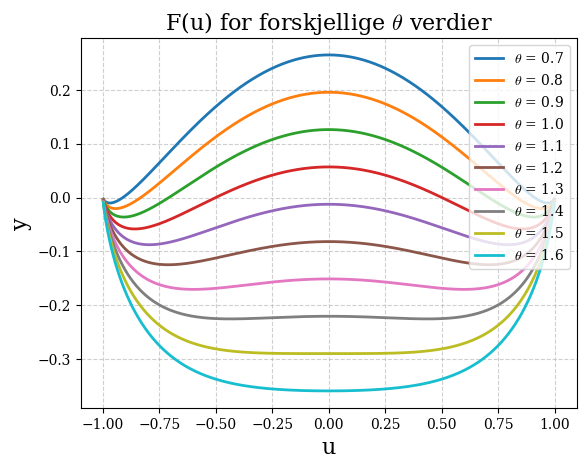

In [477]:
plot_logF(u_start, u_stop, theta_vals, theta_c)

### oppgave 1b)
Vis at Cahn-hillard likningen er uendret av transformasjonen u -> -u
Vi har likningen:  
$ \partial_t u \;-\; \nabla \cdot\bigl(M\,\nabla\bigl(f(u)\bigr) \;-\; \kappa\,\Delta u\bigr)
\;=\; 0
\quad \text{på } \Omega\times(0,T)$

Operatoren $\partial_t$ er lineær. Noe som gir 
$-\partial_t u$ ved transformasjonen

f(u) er også en ikke lineær funksjon. ved transformasjonen u -> -u får vi:  
$f(-u) = (u^2 - 1) \cdot (-u) = -f(u)$

Operatoren $\nabla $ er også lineær

Det hele resulterer i at transformasjonen u-> -u også er en løsning av Cahn-Hillard likningen



### oppgave 1c)
Vis at løsningen av Cahn-hillard likningen som er periodisk på et kvadratisk område er massekonservativt i sammenhengen at $\frac{d}{dt} \int_{\Omega} u(x,t)\,dx = 0$

### oppgave 2)
implementer en spectral løser for den biharmoniske likningen i 2d)  

$\Delta^2 u + c\,u = f
\quad \text{in } \Omega$

In [478]:
"""
Solve the biharmonic equation in 2D using the spectral method.
Parameters:
    X (ndarray): 2D array of x-coordinates.
    Y (ndarray): 2D array of y-coordinates.
    F (ndarray): 2D array representing the right-hand side of the biharmonic equation.
    c (float): Constant coefficient in the biharmonic equation.
    mean (float, optional): Desired mean value of the solution in case c = 0. Default is 0.0.

Returns:
    U (ndarray): 2D array representing the solution to the biharmonic equation.
"""

def biharmonic_solver(X, Y, F,Lx,Ly,Nx,Ny,c,mean=0.0):
    
    #fourier transform av høyre siden av likningen
    F_hat = fft2(F)

    # Bølgetall grid
    kx = fftfreq(Nx, d=(Lx/Nx))*(2*np.pi)
    ky = fftfreq(Ny, d=(Ly/Ny))*(2*np.pi)
    KX, KY = np.meshgrid(kx, ky, indexing= "ij")
    
    # Multiplikator for fourier rommet
    K2 = (KX**2 + KY**2)**2 + c
    # For å unngå å dele på 0
    K2[0,0] = 1
    
    #Vi løser nå for U i fourier rommet
    U_hat = F_hat/(K2)
    #setter [0,0] til å være lik gjennomsnittsverdien
    U_hat[0,0] = mean
    #Transformerer tilbake.
    U = np.real(ifft2(U_hat))
    return U

In [479]:
def manufacture_exact_sol(u_str,c):
    x,y = sy.symbols('x y')
    #gjør om string til funksjon eller sympy objekt
    u_sy = sy.sympify(u_str)

    laplace = lambda expr: sy.diff(expr, x,2) + sy.diff(expr,y,2)
    
    laplace1 = laplace(u_sy)
    biharmonic  = laplace(laplace1)

    f_sy = sy.simplify(biharmonic + c*u_sy)
    #print(f"u: {u_sy}")
    #print(f"f: {f_sy}")
    u = sy.lambdify((x, y), u_sy, modules='numpy')
    f = sy.lambdify((x, y), f_sy, modules='numpy')
    return f,u

In [488]:
def EOC_and_error(Nx_list,Ny_list,Lx,ly,F,c):
    error_list = np.zeros(len(Nx_list))
    EOC_list = np.zeros(len(Nx_list))
    #lager tomme lister
    for i in range(len(Nx_list)):
        Nx = Nx_list[i]
        Ny = Ny_list[i]
        #lager det kvadratiske systemet
        x = np.linspace(0,Lx,Nx, endpoint= False)
        y = np.linspace(0,Ly,Ny, endpoint= False)
        X,Y = np.meshgrid(x,y, indexing= "ij")

        f,u_exact = manufacture_exact_sol(F,c)
        U = biharmonic_solver(X,Y,f(X,Y),Lx,Ly,Nx,Ny,c,mean = 0.0)
        U += np.mean(u_exact(X,Y))
        err = np.linalg.norm(U - u_exact(X,Y), np.inf)
        error_list[i] = err
    EOC_list = np.log(error_list[:-1]/error_list[1:])/np.log((Lx/Nx_list[:-1])/(Lx/Nx_list[1:]))
    EOC_list = np.insert(EOC_list,0,np.inf)
    return Nx_list, Ny_list, error_list, EOC_list

In [490]:
Lx = 2*np.pi
ly = 4*np.pi
Nx_list = np.array([4,8,15,16,20,32])
Ny_list = 2*Nx_list
F1 = 'sin(8*(x-1))*cos(4*y)'
values1 = EOC_and_error(Nx_list,Ny_list, Lx,Ly,F1,1)

df = pd.DataFrame({
    "Nx": values1[0],
    "Ny": values1[1],
    "Error": values1[2],
    "EOC": values1[3]
})
df

,Nx,Ny,Error,EOC
0,4,8,1.818989e-12,inf
1,8,16,3.784353e+02,-47.563903
2,15,30,9.827684e+00,5.807813
3,16,32,7.863653e-14,502.942163
4,20,40,6.159517e-13,-9.224252
5,32,64,1.001514e-12,-1.034246


In [491]:
F2 = 'exp(sin(x)**2 + cos(2*y))'
k = np.arange(10)
Nx_list_1 = np.array(np.zeros(len(k), dtype=int))
for i in range(len(k)):
    Nx_list_1[i] = (4+4*k[i])
Ny_list_1 = 2*Nx_list_1
print(k)
print(Ny_list_1)
print(Nx_list_1)

values2 = EOC_and_error(Nx_list_1,Ny_list_1, Lx,Ly,F2,0)

[0 1 2 3 4 5 6 7 8 9]
[ 8 16 24 32 40 48 56 64 72 80]
[ 4  8 12 16 20 24 28 32 36 40]


In [493]:
df_1 = pd.DataFrame({
    "Nx": values2[0],
    "Ny": values2[1],
    "Error": values2[2],
    "EOC": values2[3]
})
df_1

,Nx,Ny,Error,EOC
0,4,8,9.573099e+01,inf
1,8,16,8.456927e+01,0.178852
2,12,24,1.123358e+01,4.978638
3,16,32,3.294907e-01,12.267412
4,20,40,1.254177e-02,14.647448
5,24,48,7.612873e-04,15.367403
6,28,56,4.102912e-05,18.947233
7,32,64,2.124529e-06,22.172552
8,36,72,9.783264e-08,26.133196
9,40,80,4.265664e-09,29.732775


In [510]:
Nx_list = [15,16]
Ny_list = Nx_list*2
def plot_solutions(Nx_list,Ny_list,Lx,ly,F,c):

    fig, axes = plt.subplots(len(Nx_list), 3, figsize=(15, 10))
    for i in range(len(Nx_list)):
        Nx = Nx_list[i]
        Ny = Ny_list[i]
        #lager det kvadratiske systemet
        x = np.linspace(0,Lx,Nx, endpoint= False)
        y = np.linspace(0,Ly,Ny, endpoint= False)
        X,Y = np.meshgrid(x,y, indexing= "ij")
        f,u_exact = manufacture_exact_sol(F,c)
        U = biharmonic_solver(X,Y,f(X,Y),Lx,Ly,Nx,Ny,c,mean = 0.0)
        U += np.mean(u_exact(X,Y))
        error = np.abs(u_exact(X,Y)-U)
        
        ax1 = fig.add_subplot(len(Nx_list), 3, 1 + i*3, projection='3d')
        surf1 = ax1.plot_surface(X, Y, u_exact(X,Y), cmap='viridis', edgecolor='none')
        ax1.set_title(f'Exact (Nx={Nx}, Ny={Ny})')
        fig.colorbar(surf1, ax=ax1, shrink=0.3, aspect=10, pad=0.05)
        
        # Plot numerical solution (surface plot)
        ax2 = fig.add_subplot(len(Nx_list), 3, 2 + i*3, projection='3d')
        surf2 = ax2.plot_surface(X, Y, U, cmap='viridis', edgecolor='none')
        ax2.set_title(f'Numerical (Nx={Nx}, Ny={Ny})')
        fig.colorbar(surf2, ax=ax2, shrink=0.3, aspect=10, pad=0.05)
        
        # Plot error (surface plot)
        ax3 = fig.add_subplot(len(Nx_list), 3, 3 + i*3, projection='3d')
        surf3 = ax3.plot_surface(X, Y, error, cmap='hot', edgecolor='none')
        ax3.set_title(f'Error (max={np.max(error):.2e})')
        fig.colorbar(surf3, ax=ax3, shrink=0.3, aspect=10, pad=0.05)
    
    plt.show()

    

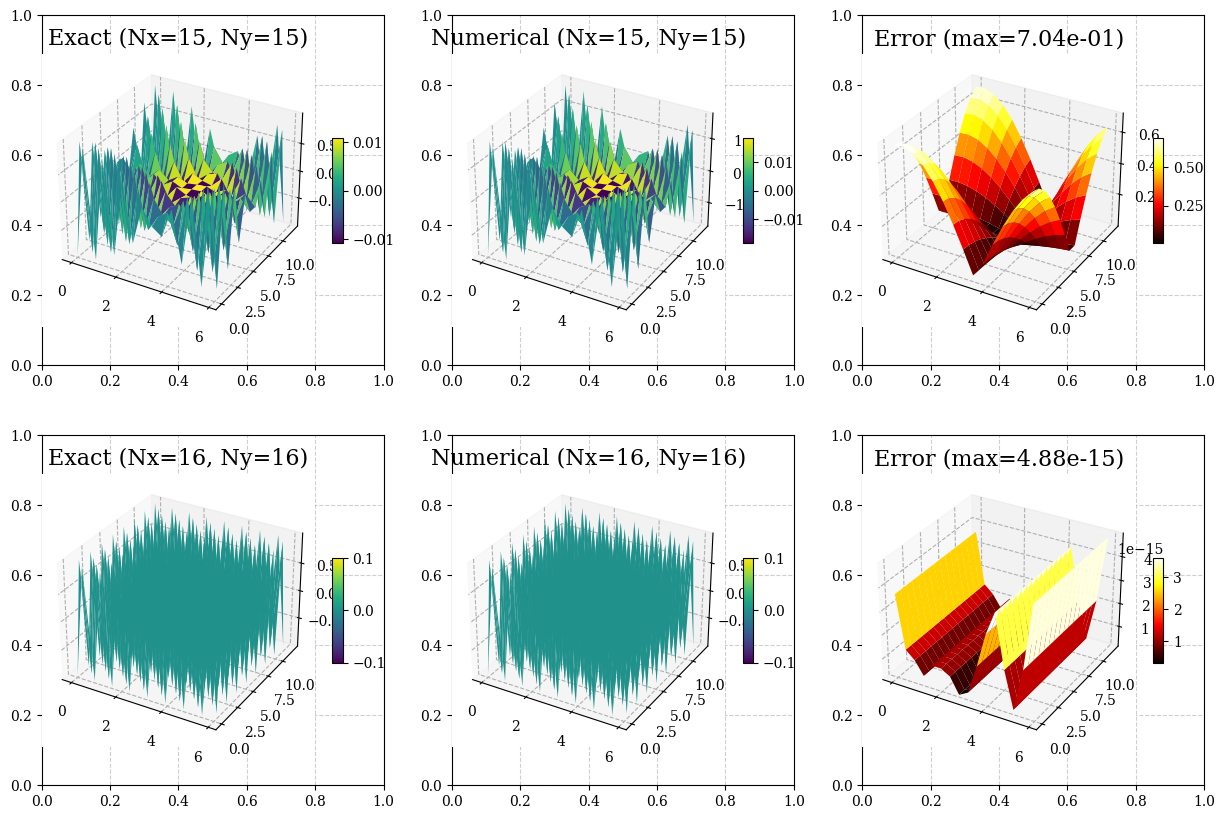

In [511]:
plot_solutions(Nx_list,Ny_list,Lx,ly,F1,c=1)

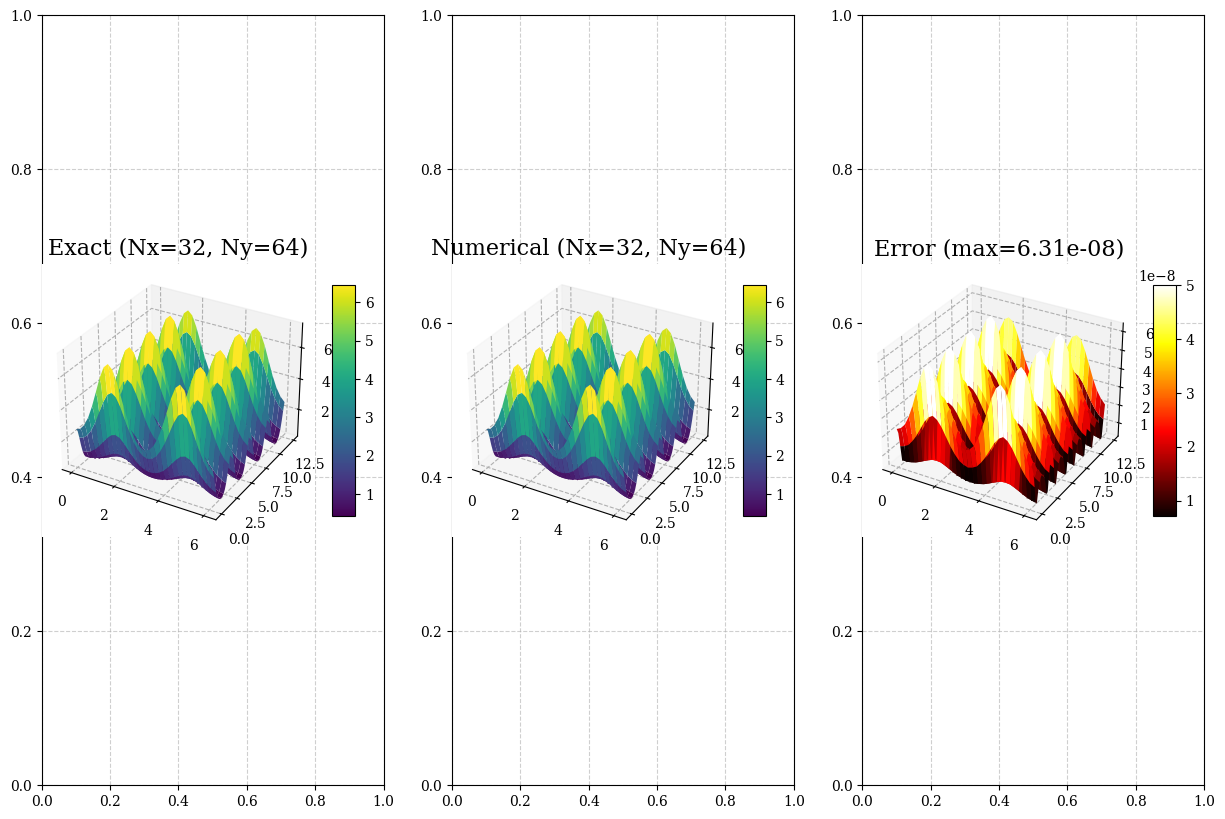

In [512]:
Nx_list = np.array([32])
Ny_list = 2*Nx_list
plot_solutions(Nx_list, Ny_list, Lx,Ly,F2,c = 0)